In [56]:
import os
os.listdir("../data/processed")

['01_fund_master_cleaned.csv',
 '02_nav_history_cleaned.csv',
 '03_aum_by_fund_house_cleaned.csv',
 '04_monthly_sip_inflows_cleaned.csv',
 '05_category_inflows_cleaned.csv',
 '06_industry_folio_count_cleaned.csv',
 '07_scheme_performance_cleaned.csv',
 '08_investor_transactions_cleaned.csv',
 '09_portfolio_holdings_cleaned.csv',
 '10_benchmark_indices_cleaned.csv']

# Mutual Fund EDA Analysis

This notebook performs Exploratory Data Analysis (EDA) on Mutual Fund datasets for BlueStock Capstone Project.

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [58]:
# Load all cleaned datasets

fund = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv",
    parse_dates=["launch_date"]
)

nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv",
    parse_dates=["date"]
)

aum = pd.read_csv(
    "../data/processed/03_aum_by_fund_house_cleaned.csv",
    parse_dates=["date"]
)

sip = pd.read_csv(
    "../data/processed/04_monthly_sip_inflows_cleaned.csv",
    parse_dates=["month"]
)

category = pd.read_csv(
    "../data/processed/05_category_inflows_cleaned.csv",
    parse_dates=["month"]
)

folio_count = pd.read_csv(
    "../data/processed/06_industry_folio_count_cleaned.csv",
    parse_dates=["month"]
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv",
    parse_dates=["transaction_date"]
)

portfolio_holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv",
    parse_dates=["portfolio_date", "portfolio_date0"]
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv",
    parse_dates=["date"]
)

In [59]:
print("Fund Master:", fund.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Industry:", folio_count.shape)
print("Performance:", performance.shape)
print("Investor:", transactions.shape)
print("Portfolio:", portfolio_holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Industry: (21, 6)
Performance: (40, 19)
Investor: (32778, 13)
Portfolio: (322, 9)
Benchmark: (8050, 3)


In [60]:
print("Fund:\n", fund.columns)

print("\nNAV:\n", nav.columns)

print("\nAUM:\n", aum.columns)

print("\nSIP:\n", sip.columns)

print("\nCategory:\n", category.columns)

print("\nFolio Count:\n", folio_count.columns)

print("\nPerformance:\n", performance.columns)

print("\nTransactions:\n", transactions.columns)

print("\nPortfolio Holdings:\n", portfolio_holdings.columns)

print("\nBenchmark:\n", benchmark.columns)

Fund:
 Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

NAV:
 Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM:
 Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP:
 Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category:
 Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Folio Count:
 Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Performance:
 Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
 

# 2. Dataset Overview

The cleaned datasets were loaded successfully from the `data/processed` directory. Before performing exploratory data analysis, the structure of each dataset was examined to understand the available features and dimensions.

Chart 1: NAV Trend Analysis (2022–2026)

Insight: Mutual fund NAVs showed an overall upward trend from 2022 to 2026 despite periods of market volatility.

In [61]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [62]:
nav_fund = pd.merge(
    nav,
    fund[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

In [63]:
nav_fund.head()

,amfi_code,date,nav,scheme_name,fund_house
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund


In [64]:
nav_fund = nav_fund.sort_values(
    by=["scheme_name", "date"]
)

In [65]:
import plotly.io as pio

pio.renderers.default = "browser"

In [66]:
fig = px.line(
    nav_fund,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

fig.show()

In [67]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

In [68]:
fig.update_layout(
    template="plotly_white",
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name"
)

Chart 2: AUM Growth by Fund House (2022–2025)

Insight: SBI Mutual Fund maintained the highest Assets Under Management (AUM), demonstrating its market leadership over the analysis period.

In [69]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[us]
 1   fund_house      90 non-null     str           
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 KB


In [70]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [71]:
aum["fund_house"].unique()

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

In [72]:
aum["year"] = aum["date"].dt.year

In [73]:
aum["year"].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

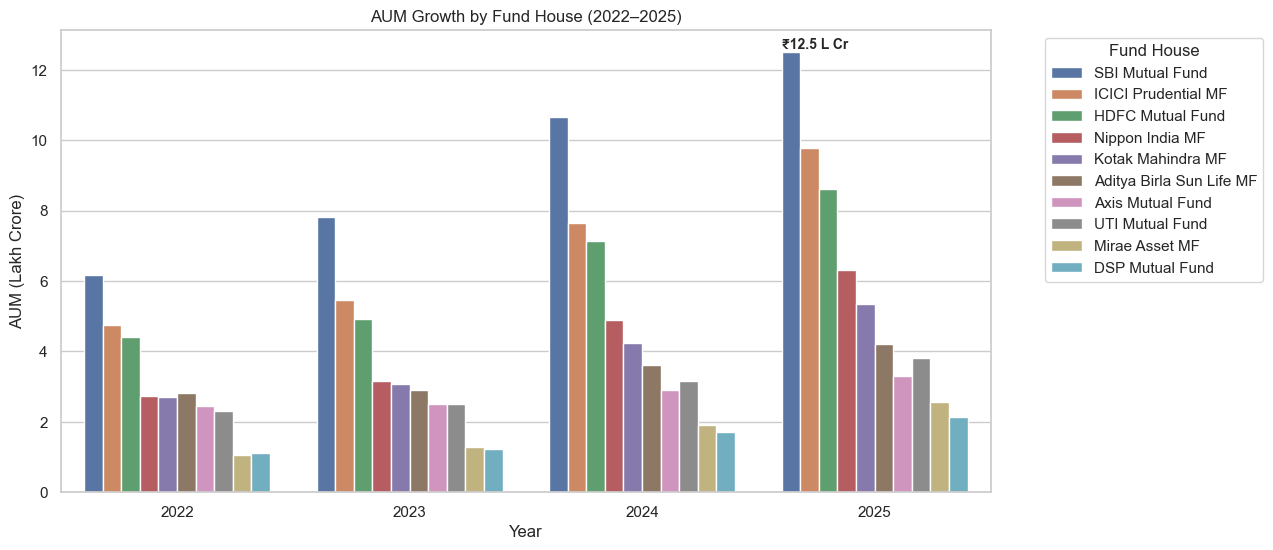

In [74]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.text(
    x=3 - 0.4,      # near the 2025 SBI bar
    y=12.6,
    s="₹12.5 L Cr",
    fontsize=10,
    fontweight="bold"
)

plt.show()

Chart 3: Monthly SIP Inflow Trend

Insight: SIP inflows increased consistently over time and reached an all-time high of ₹31,002 crore in December 2025.

In [75]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [76]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [77]:
print(sip["month"].min())
print(sip["month"].max())

2022-01-01 00:00:00
2025-12-01 00:00:00


In [78]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [79]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

Chart 4: Category-wise Net Inflow Heatmap

Insight: Equity-oriented categories such as Flexi Cap, Mid Cap, and Small Cap attracted strong investor inflows across multiple months.

In [80]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [81]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[us]
 1   category          144 non-null    str           
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 3.5 KB


In [82]:
category["category"].unique()

<StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

In [83]:
print(category["month"].min())
print(category["month"].max())

2024-04-01 00:00:00
2025-03-01 00:00:00


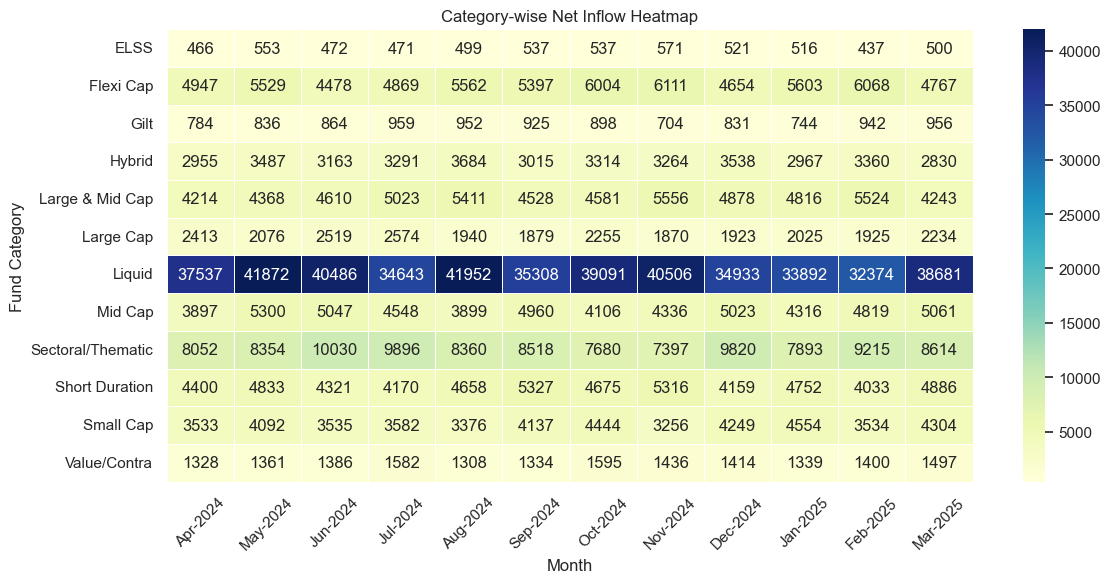

In [84]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Format month labels
heatmap_data.columns = heatmap_data.columns.strftime("%b-%Y")

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

Chart 5: Investor Age Group Distribution

Insight: Investors in the 26–35 age group formed the largest proportion of mutual fund participants in the dataset.

In [85]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

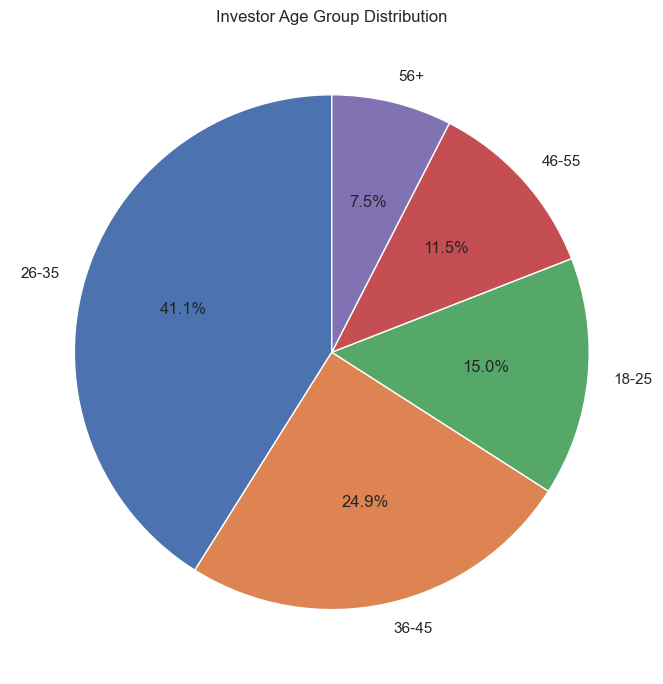

In [86]:
plt.figure(figsize=(7,7))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

Chart 6: SIP Amount Distribution by Age Group

Insight: Investment amounts varied across age groups, indicating differences in investment capacity and preferences.

In [87]:
transactions[["age_group", "amount_inr"]].head()

,age_group,amount_inr
0,56+,1834
1,18-25,392882
2,36-45,912
3,36-45,1102
4,26-35,8682


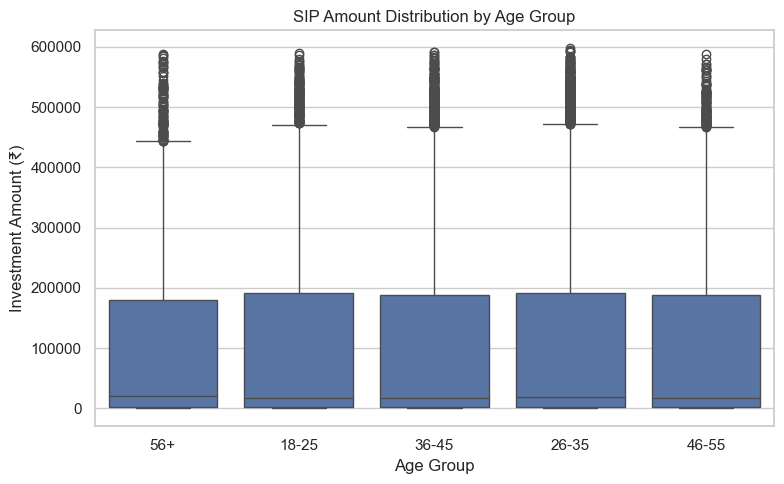

In [88]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
plt.show()

Chart 7: Gender Distribution of Investors

Insight: The dataset shows participation from multiple gender groups, reflecting broad investor representation.

In [89]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

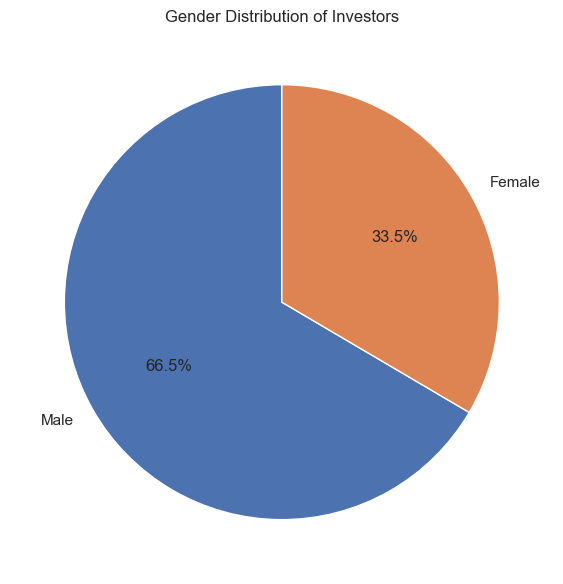

In [90]:
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")
plt.ylabel("")

plt.tight_layout()
plt.show()

Chart 8: State-wise SIP Investment Distribution

Insight: SIP investment amounts varied significantly across states, highlighting regional differences in mutual fund participation.

In [91]:
transactions["state"].value_counts()

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64

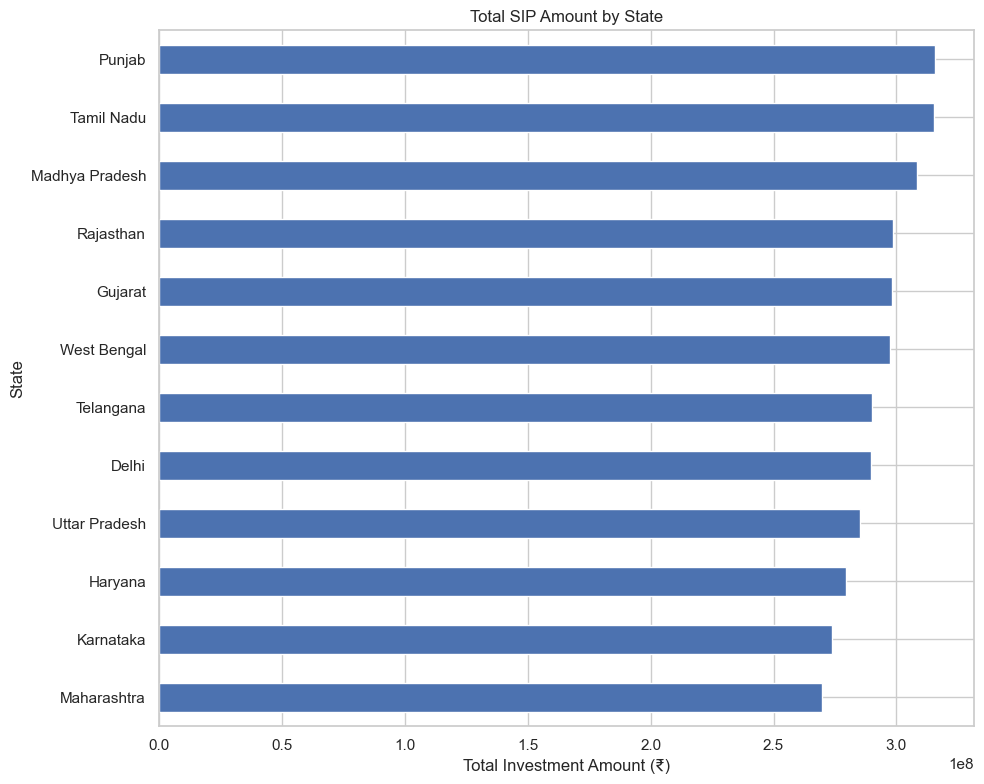

In [92]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_sip.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

Chart 9: T30 vs B30 City Tier Distribution

Insight: T30 cities contributed a major share of mutual fund investments compared to B30 cities.

In [93]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

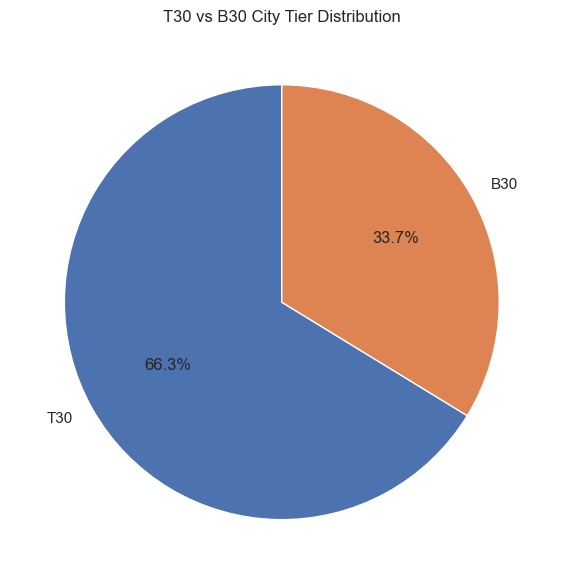

In [94]:
plt.figure(figsize=(6,6))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

Chart 10: Mutual Fund Folio Count Growth

Insight: Industry folio counts nearly doubled between 2022 and 2025, indicating rapid growth in retail investor participation.

In [95]:
folio_count.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


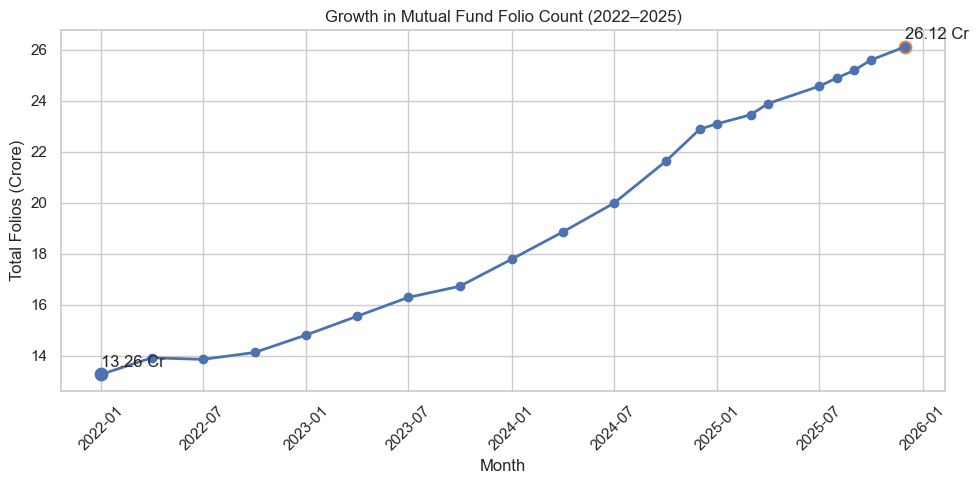

In [96]:
plt.figure(figsize=(10,5))

plt.plot(
    folio_count["month"],
    folio_count["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Mark start
plt.scatter(
    folio_count.iloc[0]["month"],
    folio_count.iloc[0]["total_folios_crore"],
    s=80
)

plt.text(
    folio_count.iloc[0]["month"],
    folio_count.iloc[0]["total_folios_crore"]+0.3,
    "13.26 Cr"
)

# Mark end
plt.scatter(
    folio_count.iloc[-1]["month"],
    folio_count.iloc[-1]["total_folios_crore"],
    s=80
)

plt.text(
    folio_count.iloc[-1]["month"],
    folio_count.iloc[-1]["total_folios_crore"]+0.3,
    "26.12 Cr"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Chart 11: NAV Return Correlation Matrix

Insight: Several mutual fund schemes exhibited strong positive correlations in daily returns, suggesting similar market movement patterns.

In [97]:
nav_fund[["date", "scheme_name", "nav"]].head()

,date,scheme_name,nav
3450,2022-01-03,ABSL Frontline Equity Fund - Regular - Growth,305.0996
3451,2022-01-04,ABSL Frontline Equity Fund - Regular - Growth,305.4514
3452,2022-01-05,ABSL Frontline Equity Fund - Regular - Growth,306.6324
3453,2022-01-06,ABSL Frontline Equity Fund - Regular - Growth,305.9800
3454,2022-01-07,ABSL Frontline Equity Fund - Regular - Growth,304.0480


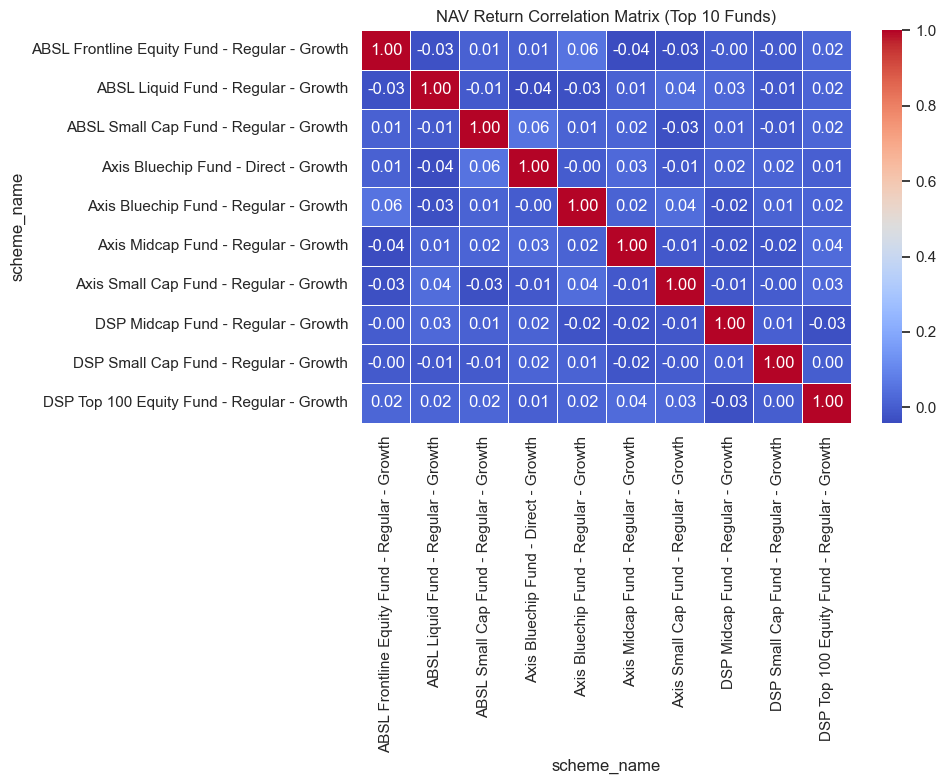

In [98]:
# Select first 10 schemes
top10 = nav_fund["scheme_name"].unique()[:10]

corr_data = nav_fund[
    nav_fund["scheme_name"].isin(top10)
]

# Convert to wide format
pivot_df = corr_data.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Daily returns
returns = pivot_df.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")

plt.tight_layout()
plt.show()

Chart 12: Sector Allocation Across Equity Funds

Insight: Portfolio allocations were concentrated in a few major sectors, reflecting diversification with sector preferences.

In [99]:
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,portfolio_date0
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,2025-12-31


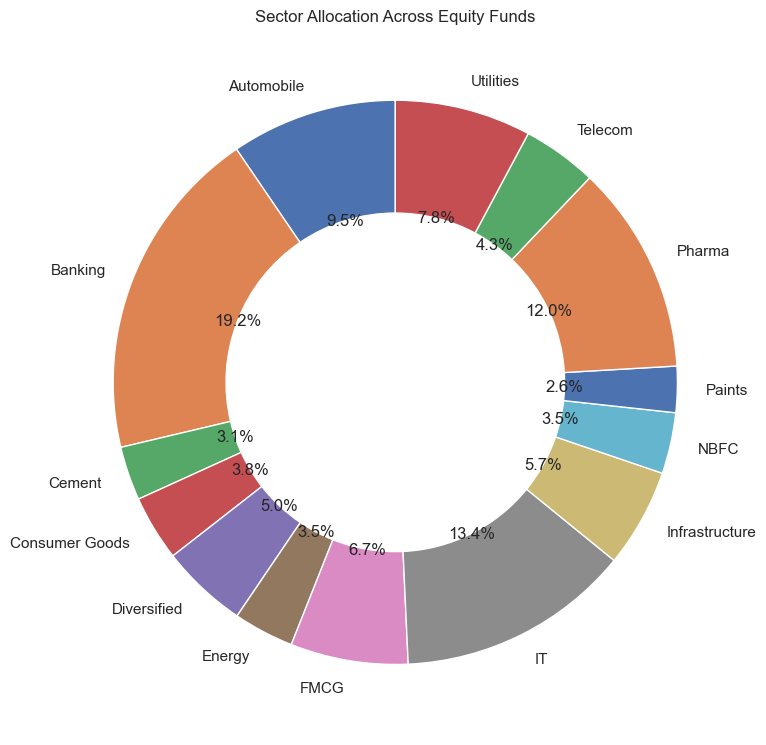

In [100]:
sector_data = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()

Chart 13: Distribution of Mutual Fund Categories

Insight: The dataset contains a balanced mix of equity, debt, hybrid, and thematic mutual fund categories.

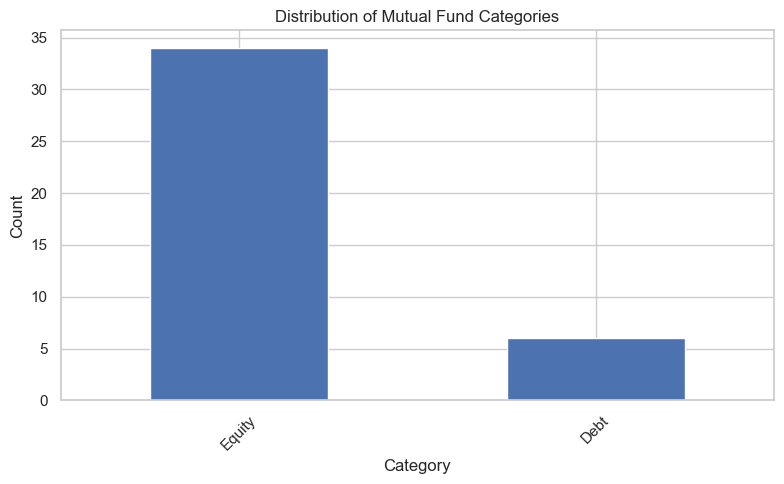

In [101]:
plt.figure(figsize=(8,5))

fund["category"].value_counts().plot(kind="bar")

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Chart 14: Risk Category Distribution

Insight: Most schemes fall under moderate to high-risk categories, indicating a strong equity-oriented investment universe.

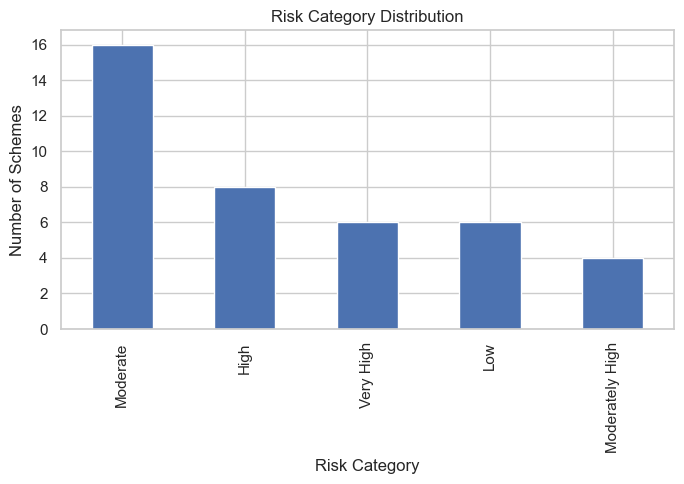

In [102]:
plt.figure(figsize=(7,5))

fund["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.tight_layout()
plt.show()

Chart 15: Expense Ratio Distribution

Insight: The majority of mutual funds have expense ratios clustered within a relatively narrow range, with only a few higher-cost schemes.

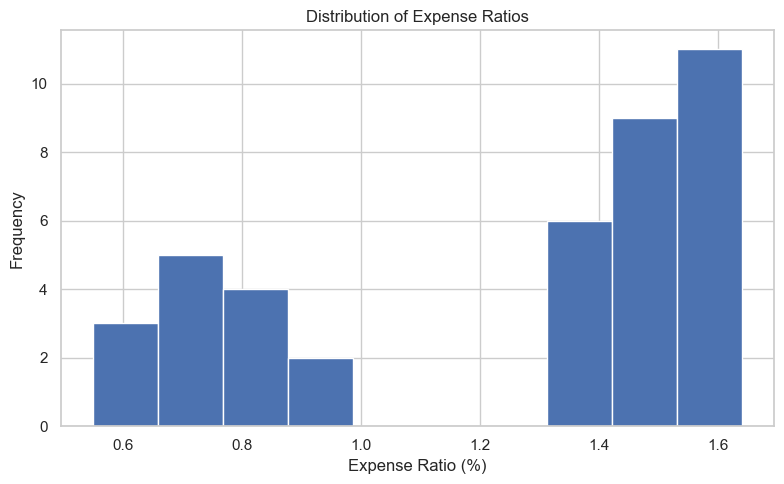

In [103]:
plt.figure(figsize=(8,5))

plt.hist(
    fund["expense_ratio_pct"],
    bins=10
)

plt.title("Distribution of Expense Ratios")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Chart 16: Morningstar Rating Distribution

Insight: Morningstar ratings are concentrated around mid-to-high ratings, suggesting generally favorable fund performance across the selected schemes.

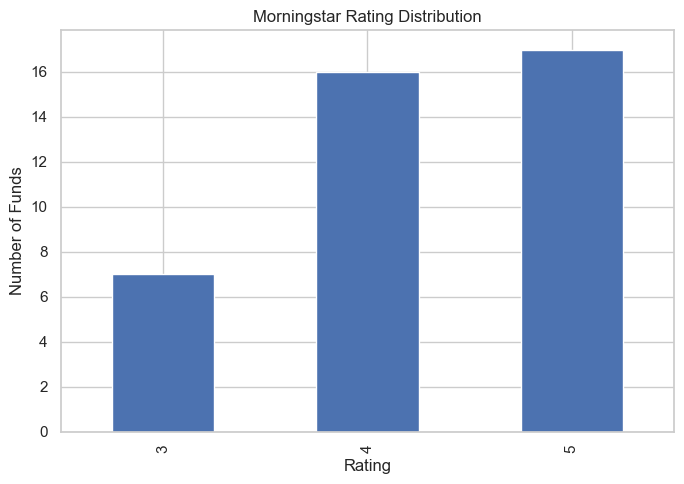

In [104]:
plt.figure(figsize=(7,5))

performance["morningstar_rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.show()

In [106]:
plt.savefig("chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

In [ ]:
fig.write_image("chart_name.png")   

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
